In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Декодирование видео в кадры

In [2]:
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import json




In [3]:
INPUT_VIDEO = 'data/input.mp4'
OUTPUT_VIDEO = 'data/output.mp4'

FRAMES_DIR = Path('results')
INPUT_DIR = FRAMES_DIR / "input"
OUTPUT_DIR = FRAMES_DIR / "output"

SKIP_TRAINING = True 

In [4]:
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cap_in = cv2.VideoCapture(INPUT_VIDEO)
cap_out = cv2.VideoCapture(OUTPUT_VIDEO)

if not cap_in.isOpened() or not cap_out.isOpened():
    raise RuntimeError("Не удалось открыть видеофайлы. Проверьте пути и наличие файлов.")\
        
        
fps_in = cap_in.get(cv2.CAP_PROP_FPS)
fps_out = cap_out.get(cv2.CAP_PROP_FPS)
count_in = int(cap_in.get(cv2.CAP_PROP_FRAME_COUNT))
count_out = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))
res_in = (int(cap_in.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap_in.get(cv2.CAP_PROP_FRAME_HEIGHT)))
res_out = (int(cap_out.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap_out.get(cv2.CAP_PROP_FRAME_HEIGHT)))

print(f"input.mp4 : {count_in} кадров, FPS={fps_in:.2f}, Размер={res_in}")
print(f"output.mp4: {count_out} кадров, FPS={fps_out:.2f}, Размер={res_out}")

# Проверка рассинхрона
if count_in != count_out:
    print("ВНИМАНИЕ: Количество кадров отличается! Синхронизация будет выполнена по меньшему значению.")
    print("Если разница >5%, рекомендуется проверить, не было ли склейки/пропуска кадров в output.mp4")

else:
    print("Рассинхрона не обнаружено.")
    






input.mp4 : 301 кадров, FPS=30.00, Размер=(1920, 1080)
output.mp4: 301 кадров, FPS=30.00, Размер=(1920, 1080)
Рассинхрона не обнаружено.


In [5]:

# Определяем количество кадров для обработки
n_frames = min(count_in, count_out)

# Сбрасываем указатели на начало
cap_in.set(cv2.CAP_PROP_POS_FRAMES, 0)
cap_out.set(cv2.CAP_PROP_POS_FRAMES, 0)

print(f"Начинаем извлечение {n_frames} пар кадров...")

for i in range(n_frames):
    ret_in, frame_in = cap_in.read()
    ret_out, frame_out = cap_out.read()
    if i == 0:
        print(ret_in)
    if not ret_in or not ret_out:
        print(f"\nПрервано на кадре {i}: один из файлов закончился раньше.")
        break
        
    # Сохраняем в PNG без сжатия (лучше для последующего поиска контуров рамок)
    cv2.imwrite(str(INPUT_DIR / f"frame_{i:05d}.png"), frame_in)
    cv2.imwrite(str(OUTPUT_DIR / f"frame_{i:05d}.png"), frame_out)

cap_in.release()
cap_out.release()
print("Готово! Кадры сохранены в папках {INPUT_DIR}, {OUTPUT_DIR}")

Начинаем извлечение 301 пар кадров...
True
Готово! Кадры сохранены в папках {INPUT_DIR}, {OUTPUT_DIR}


**Визуальная проверка синхроницации**

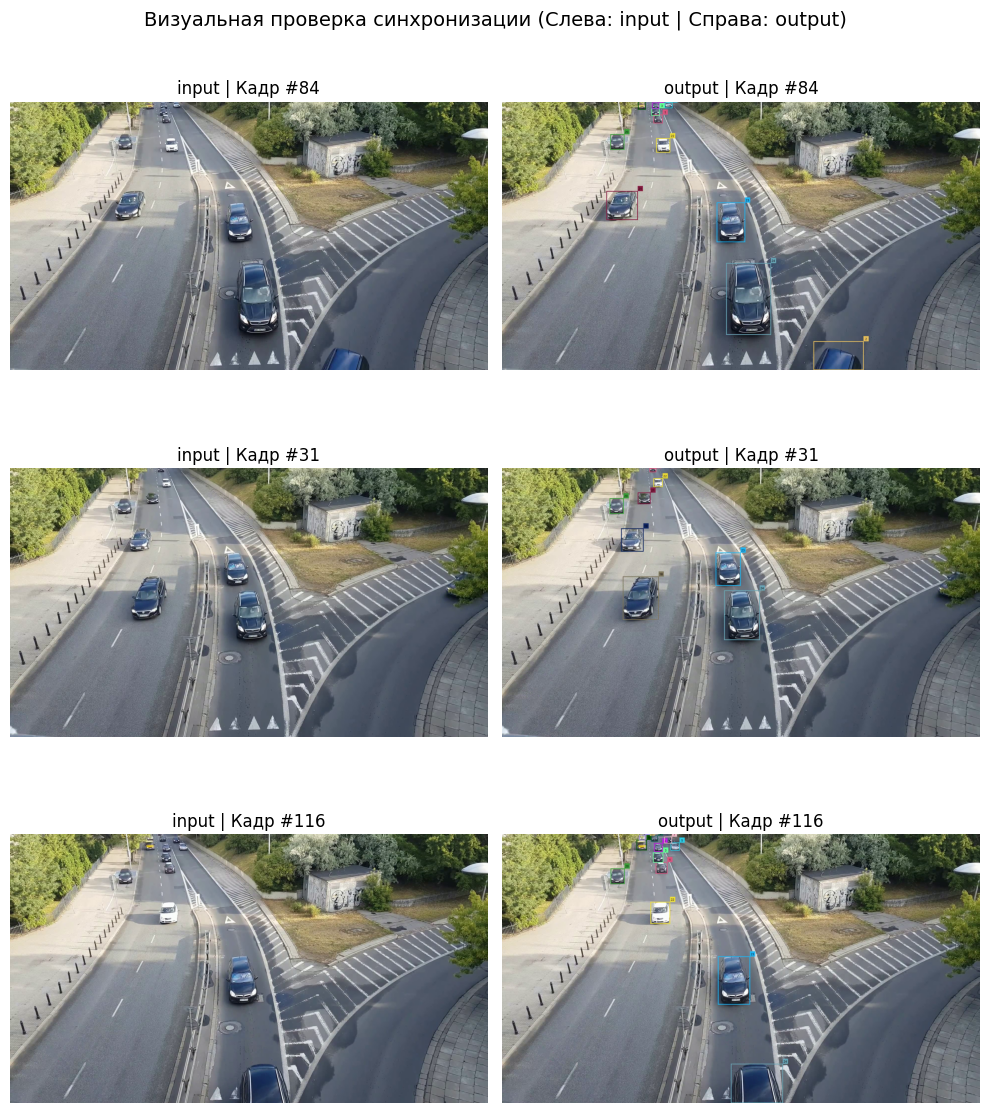

In [6]:
import random

check_indices = random.sample(range(n_frames), min(n_frames, 3))

fig, axes = plt.subplots(len(check_indices), 2, figsize=(10, 4*len(check_indices)))
fig.suptitle("Визуальная проверка синхронизации (Слева: input | Справа: output)", fontsize=14)

for idx, ax_row in zip(check_indices, axes):
    img_in = cv2.cvtColor(cv2.imread(str(INPUT_DIR / f"frame_{idx:05d}.png")), cv2.COLOR_BGR2RGB)
    img_out = cv2.cvtColor(cv2.imread(str(OUTPUT_DIR / f"frame_{idx:05d}.png")), cv2.COLOR_BGR2RGB)
    
    ax_row[0].imshow(img_in)
    ax_row[0].set_title(f"input | Кадр #{idx}")
    ax_row[0].axis("off")
    
    ax_row[1].imshow(img_out)
    ax_row[1].set_title(f"output | Кадр #{idx}")
    ax_row[1].axis("off")

plt.tight_layout()
plt.show()

### 2. Извлечение bounding box'ов через публичные CV-инструменты

In [7]:
def extract_bboxes_smart_diff(frame_in, frame_out, 
                              thresh=30,            # Порог бинаризации разницы
                              sq_kernel_size=5,     # Ядро для выделения "квадратов"/текста (MORPH_OPEN)
                              heal_kernel_size=3,   # Ядро для "лечения" рамок после вычитания (MORPH_CLOSE)
                              min_dim=20):          # Мин. ширина/высота объекта
    """
    Извлекает bbox, вычитая шум и текстовые блоки через морфологическое открытие.
    """
    # 1. Получаем маску разницы
    diff = cv2.absdiff(frame_in, frame_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    
    # 2. Изолируем "залитые" элементы (текст, мелкие артефакты, сплошные блоки)
    # MORPH_OPEN удаляет тонкие линии (рамки), оставляя только крупные/толстые пятна
    kernel_sq = cv2.getStructuringElement(cv2.MORPH_RECT, (sq_kernel_size, sq_kernel_size))
    only_noise_blocks = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_sq)
    
    # 3. Вычитаем эти блоки из общей маски
    # Остаются только тонкие линии (рамки), так как они были "съедены" открытием выше
    clean_mask = cv2.subtract(mask, only_noise_blocks)
    
    # 4. "Лечим" рамки
    # После вычитания линии могут стать прерывистыми. Замыкание (CLOSE) их соединяет.
    kernel_heal = cv2.getStructuringElement(cv2.MORPH_RECT, (heal_kernel_size, heal_kernel_size))
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel_heal)
    
    # 5. Извлекаем координаты
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    final_coords = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        # Фильтр по минимальному размеру
        if w > min_dim and h > min_dim:
            final_coords.append({
                'x': int(x), 'y': int(y), 'w': int(w), 'h': int(h),
                'area': int(w * h), 'category_id': 1
            })
            
    return final_coords, mask, only_noise_blocks, clean_mask



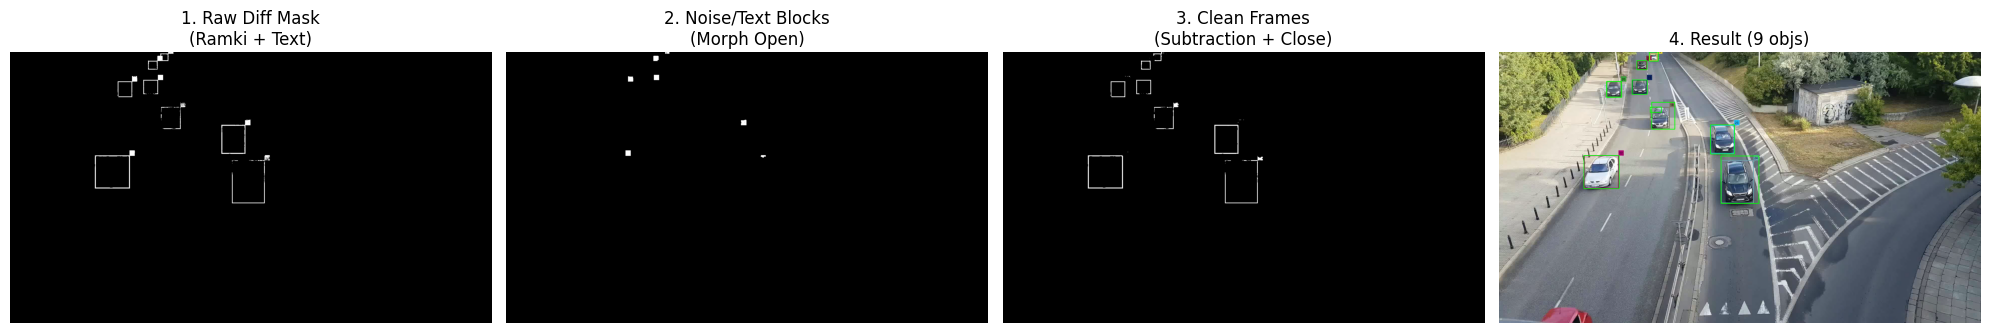

Найдено объектов: 9


In [8]:
# ТЕСТ НА ОДНОМ КАДРЕ
INPUT_DIR  = Path("results/input")
OUTPUT_DIR = Path("results/output")

# Берем первый кадр
f_in  = cv2.imread(str(sorted(INPUT_DIR.glob("*.png"))[0]))
f_out = cv2.imread(str(sorted(OUTPUT_DIR.glob("*.png"))[0]))

bboxes, raw_mask, noise_mask, clean_mask = extract_bboxes_smart_diff(f_in, f_out)

# Визуализация процесса
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(raw_mask, cmap='gray'); axes[0].set_title("1. Raw Diff Mask\n(Ramki + Text)")
axes[1].imshow(noise_mask, cmap='gray'); axes[1].set_title("2. Noise/Text Blocks\n(Morph Open)")
axes[2].imshow(clean_mask, cmap='gray'); axes[2].set_title("3. Clean Frames\n(Subtraction + Close)")

# Отрисовка найденных bbox на оригинале
vis = f_out.copy()
for b in bboxes:
    cv2.rectangle(vis, (b['x'], b['y']), (b['x']+b['w'], b['y']+b['h']), (0, 255, 0), 2)
axes[3].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[3].set_title(f"4. Result ({len(bboxes)} objs)")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Найдено объектов: {len(bboxes)}")

In [9]:
def head(bboxes_dict, n=5):
    if not bboxes_dict:
        print("Словарь пуст.")
        return

    print(f"Всего кадров: {len(bboxes_dict)}")
    print("-" * 60)
    
    keys = list(bboxes_dict.keys())[:n]
    
    for idx in keys:
        boxes = bboxes_dict[idx]
        count = len(boxes)
        print(f"Кадр #{idx} (всего объектов: {count}):")
        
        if count == 0:
            print("  - Нет объектов")
        else:
            for i, box in enumerate(boxes):
                print(f"  [{i}] x:{box['x']}, y:{box['y']}, w:{box['w']}, h:{box['h']}")
                
    print("-" * 60)
    
    

in_files  = sorted(INPUT_DIR.glob("*.png"))
out_files = sorted(OUTPUT_DIR.glob("*.png"))

all_bboxes = {}

print("Извлечение bbox методом Smart Diff...")
for i in range(len(in_files)):
    img_in  = cv2.imread(str(in_files[i]))
    img_out = cv2.imread(str(out_files[i]))
    
    if img_in is None or img_out is None: continue
    
    # Вызываем обновленную функцию
    bboxes, _, _, _ = extract_bboxes_smart_diff(img_in, img_out)
    all_bboxes[i] = bboxes

total_objs = sum(len(v) for v in all_bboxes.values())
print(f"Готово. Кадров: {len(all_bboxes)}, Объектов: {total_objs}")

head(all_bboxes)

Извлечение bbox методом Smart Diff...
Готово. Кадров: 301, Объектов: 3210
Всего кадров: 301
------------------------------------------------------------
Кадр #0 (всего объектов: 9):
  [0] x:884, y:414, w:151, h:189
  [1] x:338, y:412, w:140, h:132
  [2] x:842, y:290, w:96, h:116
  [3] x:602, y:219, w:45, h:21
  [4] x:608, y:200, w:92, h:107
  [5] x:428, y:117, w:60, h:63
  [6] x:530, y:111, w:60, h:57
  [7] x:549, y:34, w:40, h:36
  [8] x:598, y:0, w:36, h:36
Кадр #1 (всего объектов: 9):
  [0] x:884, y:434, w:132, h:171
  [1] x:328, y:422, w:144, h:136
  [2] x:988, y:413, w:48, h:23
  [3] x:842, y:292, w:100, h:116
  [4] x:600, y:204, w:99, h:110
  [5] x:429, y:117, w:58, h:63
  [6] x:531, y:114, w:59, h:58
  [7] x:549, y:36, w:39, h:36
  [8] x:598, y:3, w:37, h:34
Кадр #2 (всего объектов: 9):
  [0] x:885, y:434, w:131, h:174
  [1] x:316, y:432, w:150, h:142
  [2] x:1015, y:415, w:21, h:21
  [3] x:844, y:294, w:100, h:116
  [4] x:608, y:209, w:90, h:111
  [5] x:530, y:117, w:60, h:59
 

In [10]:
model = YOLO('yolov8n.pt')



all_bboxes_yolo = {}
conf_thresh = 0.5

print("Извлечение bbox методом YOLOv8...")
for i in range(len(in_files)):
    img = cv2.imread(str(in_files[i]))
    if img is None: continue

    results = model(img, conf=conf_thresh, verbose=False)
    frame_boxes = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            w = x2 - x1
            h = y2 - y1
            frame_boxes.append({
                'x': int(x1), 'y': int(y1), 'w': int(w), 'h': int(h),
                'area': int(w * h), 'category_id': 1
            })
    all_bboxes_yolo[i] = frame_boxes

total_yolo = sum(len(v) for v in all_bboxes_yolo.values())
print(f"Готово. Кадров: {len(all_bboxes_yolo)}, Объектов: {total_yolo}")
head(all_bboxes_yolo)

Извлечение bbox методом YOLOv8...
Готово. Кадров: 301, Объектов: 1554
Всего кадров: 301
------------------------------------------------------------
Кадр #0 (всего объектов: 5):
  [0] x:424, y:118, w:64, h:60
  [1] x:606, y:218, w:70, h:84
  [2] x:338, y:416, w:141, h:128
  [3] x:535, y:117, w:57, h:48
  [4] x:895, y:434, w:117, h:170
Кадр #1 (всего объектов: 4):
  [0] x:602, y:223, w:73, h:85
  [1] x:423, y:116, w:67, h:61
  [2] x:327, y:421, w:147, h:134
  [3] x:896, y:434, w:116, h:171
Кадр #2 (всего объектов: 4):
  [0] x:423, y:119, w:63, h:58
  [1] x:601, y:229, w:74, h:83
  [2] x:319, y:433, w:147, h:138
  [3] x:533, y:123, w:62, h:50
Кадр #3 (всего объектов: 5):
  [0] x:600, y:230, w:76, h:88
  [1] x:422, y:120, w:67, h:57
  [2] x:534, y:126, w:57, h:50
  [3] x:310, y:444, w:148, h:139
  [4] x:896, y:438, w:117, h:172
Кадр #4 (всего объектов: 5):
  [0] x:600, y:239, w:75, h:86
  [1] x:424, y:118, w:63, h:59
  [2] x:536, y:126, w:57, h:54
  [3] x:299, y:452, w:153, h:148
  [4] x:

### 3. Оценить качество извлеченной разметки сравнивая с оригиналом по IoU

In [11]:
def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    union_area = (w1 * h1) + (w2 * h2) - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

def evaluate_methods(pred_dict, gt_dict, iou_thresh=0.5):
    all_ious = []
    tp, fp, fn = 0, 0, 0
    
    common_frames = sorted(set(pred_dict.keys()) & set(gt_dict.keys()))
    
    for idx in common_frames:
        preds = pred_dict[idx]
        gts = gt_dict[idx]
        matched_pred = set()
        
        for gt in gts:
            gt_box = [gt['x'], gt['y'], gt['w'], gt['h']]
            best_iou = 0
            best_idx = -1
            
            for i, pred in enumerate(preds):
                if i in matched_pred: continue
                pred_box = [pred['x'], pred['y'], pred['w'], pred['h']]
                iou = calculate_iou(gt_box, pred_box)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
            
            if best_iou >= iou_thresh and best_idx != -1:
                all_ious.append(best_iou)
                tp += 1
                matched_pred.add(best_idx)
            else:
                fn += 1
        
        fp += len(preds) - len(matched_pred)

    mean_iou = np.mean(all_ious) if all_ious else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fp) if (tp + fn) > 0 else 0.0 # Исправлено: recall = TP / (TP + FN)
    
    return mean_iou, precision, recall, all_ious

In [12]:
import xml.etree.ElementTree as ET
from collections import defaultdict

def parse_cvat_xml(xml_path="annotations.xml"):
    """
    Парсер для формата CVAT (track/box с атрибутами xtl, ytl, xbr, ybr, outside, frame).
    Возвращает словарь: {frame_idx: [bbox_dict, ...]}
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    gt_bboxes = defaultdict(list)

    for track in root.findall('track'):
        # Игнорируем классы, приводим к единому category_id=1 как в остальной работе
        for box in track.findall('box'):
            # Пропускаем кадры, где объект отсутствует (outside="1")
            if box.get('outside') == '1':
                continue

            frame_idx = int(box.get('frame'))
            xtl = float(box.get('xtl', 0))
            ytl = float(box.get('ytl', 0))
            xbr = float(box.get('xbr', 0))
            ybr = float(box.get('ybr', 0))

            x, y = int(xtl), int(ytl)
            w, h = int(xbr - xtl), int(ybr - ytl)

            if w > 0 and h > 0:
                gt_bboxes[frame_idx].append({
                    'x': x, 'y': y, 'w': w, 'h': h,
                    'area': w * h, 'category_id': 1
                })

    gt_bboxes = dict(gt_bboxes)
    total_objs = sum(len(v) for v in gt_bboxes.values())
    print(f"Загружено Ground Truth из CVAT XML: {len(gt_bboxes)} кадров, {total_objs} объектов")
    return gt_bboxes

# Загружаем истинную разметку
all_bboxes_gt = parse_cvat_xml("annotations.xml")

Загружено Ground Truth из CVAT XML: 901 кадров, 9659 объектов


Сравнение методов с ОРИГИНАЛЬНОЙ разметкой (XML):
Метод        | Mean IoU   | Precision  | Recall    
--------------------------------------------------
Smart Diff   | 0.8858     | 0.8171     | 0.8171    
YOLOv8       | 0.8653     | 0.9266     | 0.9266    


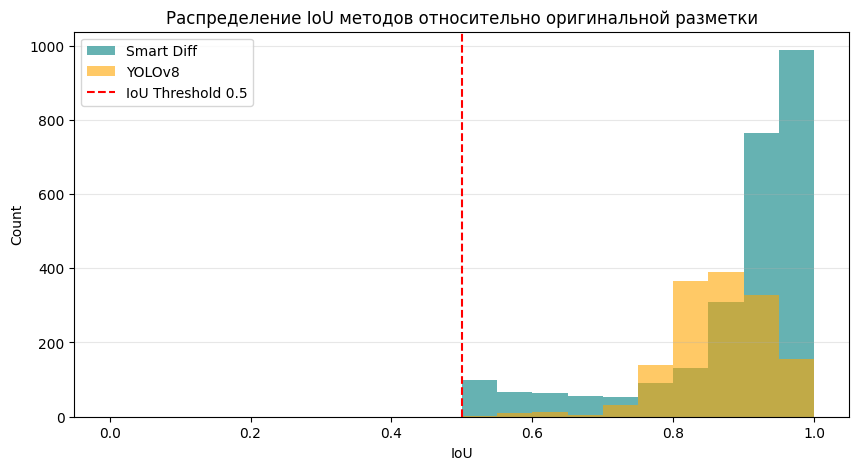

Сравнение Smart Diff vs YOLOv8 (Эталон):
Mean IoU:  0.8289
Precision: 0.4093
Recall:    0.4093


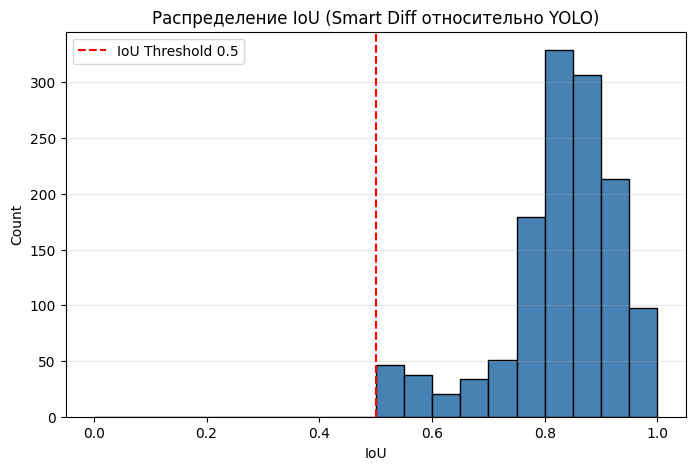

In [13]:
# Обновляем вызов оценки: сравниваем ваш метод и YOLO с ИСТИННЫМ GT
mean_iou_smart, prec_smart, rec_smart, iou_smart = evaluate_methods(all_bboxes, all_bboxes_gt)
mean_iou_yolo, prec_yolo, rec_yolo, iou_yolo = evaluate_methods(all_bboxes_yolo, all_bboxes_gt)

print("Сравнение методов с ОРИГИНАЛЬНОЙ разметкой (XML):")
print(f"{'Метод':<12} | {'Mean IoU':<10} | {'Precision':<10} | {'Recall':<10}")
print("-" * 50)
print(f"{'Smart Diff':<12} | {mean_iou_smart:<10.4f} | {prec_smart:<10.4f} | {rec_smart:<10.4f}")
print(f"{'YOLOv8':<12} | {mean_iou_yolo:<10.4f} | {prec_yolo:<10.4f} | {rec_yolo:<10.4f}")

# Визуализация распределения IoU
plt.figure(figsize=(10, 5))
if iou_smart:
    plt.hist(iou_smart, bins=np.arange(0, 1.05, 0.05), alpha=0.6, label='Smart Diff', color='teal')
if iou_yolo:
    plt.hist(iou_yolo, bins=np.arange(0, 1.05, 0.05), alpha=0.6, label='YOLOv8', color='orange')
plt.axvline(x=0.5, color='red', linestyle='--', label='IoU Threshold 0.5')
plt.title('Распределение IoU методов относительно оригинальной разметки')
plt.xlabel('IoU'); plt.ylabel('Count')
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.show()



# Оцениваем Smart Diff (all_bboxes) относительно YOLO (all_bboxes_yolo)
mean_iou, precision, recall, iou_list = evaluate_methods(all_bboxes, all_bboxes_yolo)

print(f"Сравнение Smart Diff vs YOLOv8 (Эталон):")
print(f"Mean IoU:  {mean_iou:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

plt.figure(figsize=(8, 5))
if iou_list:
    plt.hist(iou_list, bins=np.arange(0, 1.05, 0.05), edgecolor='black', color='steelblue')
    plt.axvline(x=0.5, color='red', linestyle='--', label='IoU Threshold 0.5')
    plt.title('Распределение IoU (Smart Diff относительно YOLO)')
    plt.xlabel('IoU')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Нет совпадений', ha='center')
plt.show()

### 4. Генерация датасета COCO

In [14]:
from datetime import datetime

def save_coco(bboxes_dict, path="annotations.json"):
    # Получаем размеры из первого кадра
    first_idx = sorted(bboxes_dict.keys())[0]
    img_path = str(INPUT_DIR / f"frame_{first_idx:05d}.png")
    h, w = cv2.imread(img_path).shape[:2]

    coco = {
        "info": {"description": "Lab3 Dataset", "version": "1.0", "year": 2026},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "object", "supercategory": ""}]
    }
    
    ann_id = 1
    for idx in sorted(bboxes_dict.keys()):
        coco["images"].append({
            "id": idx, 
            "file_name": f"frame_{idx:05d}.png", 
            "width": w, 
            "height": h
        })
        
        for box in bboxes_dict[idx]:
            coco["annotations"].append({
                "id": ann_id,
                "image_id": idx,
                "category_id": 1,
                "bbox": [box['x'], box['y'], box['w'], box['h']],
                "area": box['w'] * box['h'],
                "iscrowd": 0
            })
            ann_id += 1

    with open(path, 'w') as f:
        json.dump(coco, f, indent=2)
    print(f"COCO saved to {path}. Images: {len(coco['images'])}, Anns: {len(coco['annotations'])}")

save_coco(all_bboxes, "annotations.json")

COCO saved to annotations.json. Images: 301, Anns: 3210


### 5. Обучить детектор объектов на основе готовой архитектуры из torchvision.models.detection (например, Faster R-CNN или RetinaNet).

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import nms
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split

from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

class FrameBBoxDataset(Dataset):
    def __init__(self, images_dir, annotations_dict):
        self.images_dir = images_dir
        self.indices = sorted(annotations_dict.keys())
        self.anns = annotations_dict

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        frame_id = self.indices[idx]
        img_path = self.images_dir / f"frame_{frame_id:05d}.png"
        img = Image.open(img_path).convert("RGB")
        img_tensor = TF.to_tensor(img)  # [C, H, W], [0, 1]

        boxes, labels = [], []
        for b in self.anns[frame_id]:
            boxes.append([b['x'], b['y'], b['x'] + b['w'], b['y'] + b['h']])
            labels.append(1)  # 1 класс + фон = 2

        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros(0, dtype=torch.int64),
            'image_id': torch.tensor([frame_id])
        }
        return img_tensor, target

def collate_fn(batch):
    return list(zip(*batch))

# Разделение 80/20
all_idx = sorted(all_bboxes.keys())
train_idx, val_idx = train_test_split(all_idx, test_size=0.2, random_state=42, shuffle=False)
train_anns = {k: all_bboxes[k] for k in train_idx}
val_anns   = {k: all_bboxes[k] for k in val_idx}

train_ds = FrameBBoxDataset(INPUT_DIR, train_anns)
val_ds   = FrameBBoxDataset(INPUT_DIR, val_anns)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} кадров")

Устройство: cpu
Train: 240 | Val: 61 кадров


In [16]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Загружаем предобученную модель
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights, progress=False)

# Получаем количество входных признаков для классификатора
in_features = model.roi_heads.box_predictor.cls_score.in_features

# ЗАМЕНЯЕМ ПРЕДИКТОР НА ПРАВИЛЬНЫЙ
# FastRCNNPredictor сам создаст два слоя: cls_score (классы) и bbox_pred (координаты)
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2) # 1 класс + фон

model.to(device)

# Оптимизатор берет все параметры, требующие градиента
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Модель успешно инициализирована с правильным head")

Модель успешно инициализирована с правильным head


**Цикл обучения с Early Stopping + График потерь**

In [17]:
import os

# Проверяем флаг
if not SKIP_TRAINING:
    num_epochs = 30
    patience = 6
    best_val_loss = float('inf')
    early_stop_cnt = 0
    train_losses, val_losses = [], []

    print("🚀 Начинаем обучение Faster R-CNN...")
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        
        for images, targets in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            optimizer.zero_grad()
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train = epoch_loss / len(train_loader)
        
        # Валидация
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                val_loss += sum(model(images, targets).values()).item()
        avg_val = val_loss / len(val_loader)
        
        scheduler.step(avg_val)
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            early_stop_cnt = 0
            torch.save(model.state_dict(), "best_frcnn.pth")
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= patience:
                print(f"️ Early Stopping сработал на эпохе {epoch+1}")
                break

    model.load_state_dict(torch.load("best_frcnn.pth"))
    print("✅ Обучение завершено. Лучшая модель загружена.")
    
    # Сохраняем истории потерь, чтобы построить график даже если мы их не считали сейчас
    import json
    with open('training_history.json', 'w') as f:
        json.dump({'train': train_losses, 'val': val_losses}, f)

else:
    print("⏭️ Пропуск обучения. Загрузка сохраненной модели 'best_frcnn.pth'...")
    if os.path.exists("best_frcnn.pth"):
        model.load_state_dict(torch.load("best_frcnn.pth"))
        model.eval()
        print("✅ Модель загружена.")
        
        # Загружаем историю потерь для графика, если она есть
        try:
            with open('training_history.json', 'r') as f:
                history = json.load(f)
                train_losses = history['train']
                val_losses = history['val']
        except FileNotFoundError:
            train_losses, val_losses = [], []
            print("⚠️ История обучения не найдена, график потерь будет пустым.")
    else:
        raise FileNotFoundError("Файл 'best_frcnn.pth' не найден. Сначала выполните обучение с SKIP_TRAINING = False")

# График потерь (выполняется всегда, если есть данные)
if train_losses:
    plt.figure(figsize=(8, 5))
    epochs = range(1, len(train_losses)+1)
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, val_losses, 'r-s', label='Val Loss', markersize=4)
    plt.title('Динамика потерь (Loss) при обучении Faster R-CNN')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Нет данных для построения графика потерь.")

⏭️ Пропуск обучения. Загрузка сохраненной модели 'best_frcnn.pth'...
✅ Модель загружена.
⚠️ История обучения не найдена, график потерь будет пустым.
Нет данных для построения графика потерь.


### 6. Оценка модели по mAP@0.5 и PR-кривая

mAP@0.5 на валидации: 0.8252


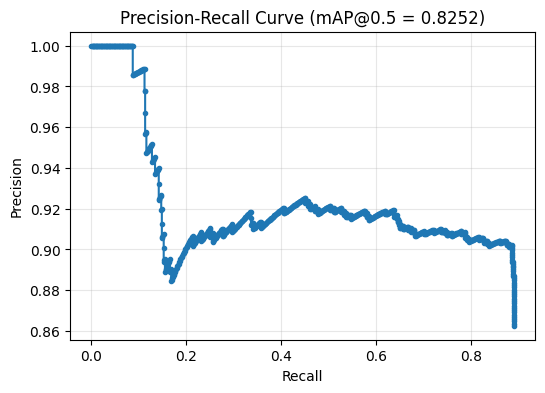

In [18]:
def compute_map05(preds_dict, gt_dict, iou_thresh=0.5, score_thresh=0.5):
    tp, fp, confs = [], [], []
    gt_used = {}
    
    for img_id in sorted(preds_dict.keys()):
        preds = sorted(preds_dict[img_id], key=lambda x: x['score'], reverse=True)
        gts = gt_dict.get(img_id, [])
        
        for p in preds:
            if p['score'] < score_thresh: continue
            px1, py1, px2, py2 = p['box']
            best_iou, matched = 0.0, -1
            
            for i, g in enumerate(gts):
                iou = calculate_iou([px1, py1, px2-px1, py2-py1],
                                    [g['x'], g['y'], g['w'], g['h']])
                if iou > best_iou:
                    best_iou, matched = iou, i
                    
            if best_iou >= iou_thresh and matched not in gt_used.get(img_id, set()):
                tp.append(1); fp.append(0)
                gt_used.setdefault(img_id, set()).add(matched)
            else:
                tp.append(0); fp.append(1)
            confs.append(p['score'])
            
    if not confs: return 0.0, np.array([]), np.array([])
    
    idx = np.argsort(-np.array(confs))
    tp, fp = np.array(tp)[idx], np.array(fp)[idx]
    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    rec = tp_cum / max(1, len([b for bs in gt_dict.values() for b in bs]))
    prec = tp_cum / np.maximum(1, tp_cum + fp_cum)
    
    # Interpolated AP (COCO style)
    prec_interp = np.maximum.accumulate(prec[::-1])[::-1]
    
    
    if len(rec) > 1:
        
        ap = np.sum((rec[1:] - rec[:-1]) * (prec_interp[1:] + prec_interp[:-1]) / 2)
    else:
        ap = 0.0
        
    return ap, rec, prec
    

# Инференс на валидации
val_preds = {}
model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for t, out in zip(targets, outputs):
            img_id = int(t['image_id'].item())
            boxes = out['boxes'].cpu().numpy()
            scores = out['scores'].cpu().numpy()
            keep = nms(torch.tensor(boxes), torch.tensor(scores), 0.5).numpy()
            val_preds[img_id] = [{'box': boxes[i], 'score': scores[i]} for i in keep]

mAP, rec_curve, prec_curve = compute_map05(val_preds, val_anns)
print(f"mAP@0.5 на валидации: {mAP:.4f}")

plt.figure(figsize=(6,4))
plt.plot(rec_curve, prec_curve, marker='.', linestyle='-')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (mAP@0.5 = {mAP:.4f})')
plt.grid(True, alpha=0.3); plt.show()

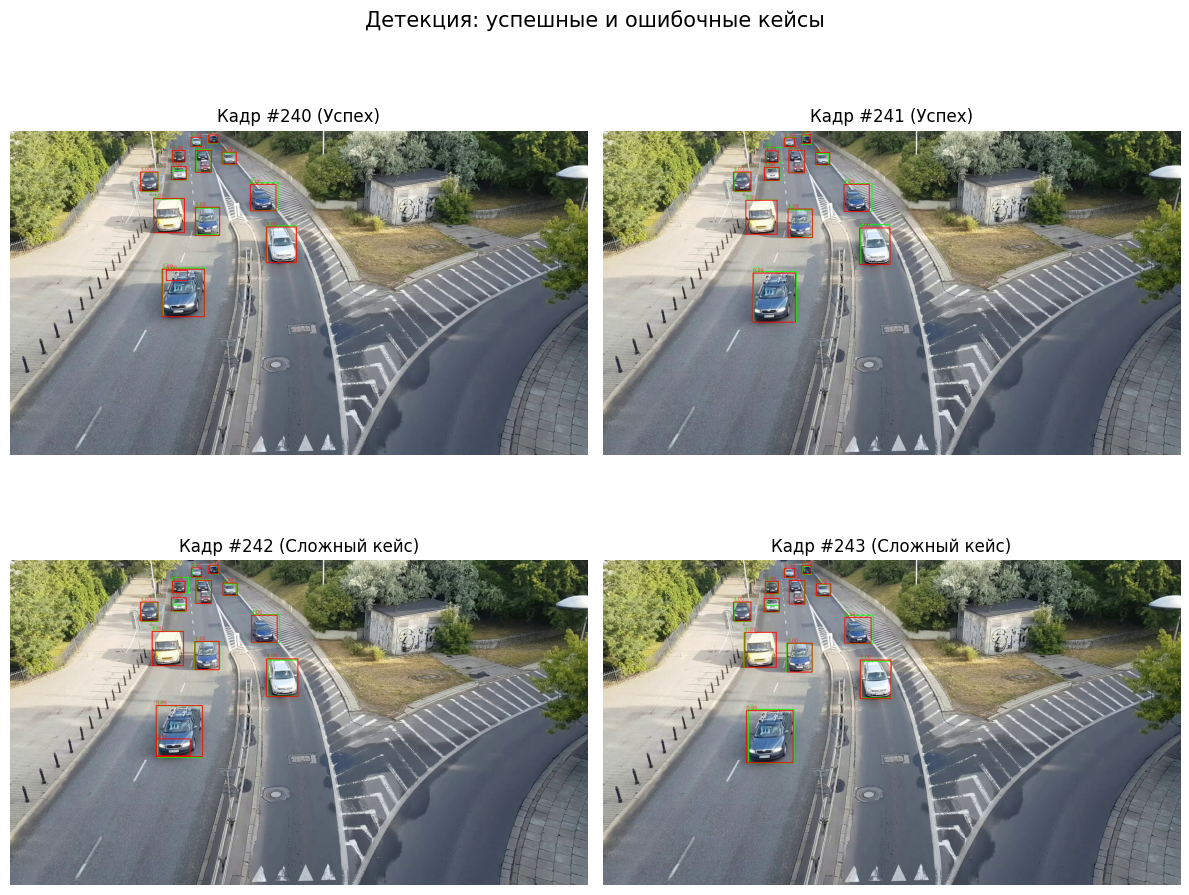

In [21]:
def draw_boxes(img_path, preds, gts, save_path=None):
    img = cv2.imread(img_path)
    vis = img.copy()
    # GT: зелёные
    for b in gts:
        cv2.rectangle(vis, (b['x'], b['y']), (b['x']+b['w'], b['y']+b['h']), (0,255,0), 2)
        cv2.putText(vis, 'GT', (b['x'], b['y']-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    # Pred: красные
    for p in preds:
        if p['score'] > 0.4:
            x1,y1,x2,y2 = map(int, p['box'])
            cv2.rectangle(vis, (x1,y1), (x2,y2), (0,0,255), 2)
            cv2.putText(vis, f"{p['score']:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
    if save_path: cv2.imwrite(save_path, vis)
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Детекция: успешные и ошибочные кейсы", fontsize=15)
ids = sorted(val_preds.keys())
for i, idx in enumerate(ids[:4]):
    r, c = i//2, i%2
    axes[r, c].imshow(draw_boxes(str(INPUT_DIR/f"frame_{idx:05d}.png"), val_preds[idx], val_anns.get(idx, [])))
    axes[r, c].set_title(f"Кадр #{idx} {'(Успех)' if i<2 else '(Сложный кейс)'}")
    axes[r, c].axis('off')
plt.tight_layout(); plt.show()

In [20]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('results/output_annotated.mp4', fourcc, fps_in, res_in)
print("Генерация видео с извлечённой разметкой...")
for i in range(n_frames):
    frame = cv2.imread(str(INPUT_DIR / f"frame_{i:05d}.png"))
    if frame is None: break
    
    # Берём предсказания для val, GT для train
    if i in val_preds:
        boxes = [(int(b['box'][0]), int(b['box'][1]), int(b['box'][2]), int(b['box'][3])) 
                 for b in val_preds[i] if b['score']>0.5]
    elif i in train_anns:
        boxes = [(b['x'], b['y'], b['x']+b['w'], b['y']+b['h']) for b in train_anns[i]]
    else: continue
        
    for (x1,y1,x2,y2) in boxes:
        cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
    out.write(frame)
out.release()
print("Сохранено: results/output_annotated.mp4")

Генерация видео с извлечённой разметкой...
Сохранено: results/output_annotated.mp4
